<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/statprak_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Water Quality. Исследование качества воды**

https://www.kaggle.com/datasets/adityakadiwal/water-potability?resource=download

## **Описание датасета (перевод из Kaggle)**

Доступ к безопасной питьевой воде имеет жизненно важное значение для здоровья, является одним из основных прав человека и составной частью эффективной политики в области охраны здоровья. Это важный вопрос, касающийся здоровья и развития на национальном, региональном и местном уровнях. В некоторых регионах было доказано, что инвестиции в водоснабжение и санитарию могут приносить чистую экономическую выгоду, поскольку сокращение негативных последствий для здоровья и расходов на здравоохранение перевешивает затраты на реализацию соответствующих мер.

## **Columns и что значат**

Данный датасет содержит 10 признаков (один целевой), которые описывают качество воды для 3276 различных водоемов:
1. pH: уровень pH воды (от 0 до 14).
2. Жесткость: способность воды вызывать осаждение мыла в мг/л.
3. Твердые вещества: общее количество растворенных твердых веществ в ppm.
4. Хлорамины: количество хлораминов в ppm.
5. Сульфаты: количество растворенных сульфатов в мг/л.
6. Проводимость: электропроводность воды в мкСм/см.
7. Органический углерод: количество органического углерода в ppm.
8. Трихлорметаны: количество трихлорметанов в мкг/л.
9. Мутность: показатель светопроницаемости воды в NTU.
10. Пригодность для питья: указывает, безопасна ли вода для потребления человеком. Пригодна для питья — 1, непригодна для питья — 0.

## **Загрузка и первый взгляд**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid")

df = pd.read_csv('water_potability.csv')
display(df.head())

print("\n" + "="*40)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ:")
print("="*40)
df.info()

print("\n" + "="*40)
print("ОСНОВНАЯ СТАТИСТИКА")
print("="*40)
display(df.describe())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

ОСНОВНАЯ СТАТИСТИКА


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### Выводы из первичного осмотра

1) В датасете действительно 3276 объектов, но есть пропуски в ph, Sulfate, Trihalomethanes. С ними нужно будет что-то сделать.

2) В датасете нет категориальных признаков, а значит это упростит нам предобработку

3) Масштабы признаков очень сильно отличаются, а значит нужно обязательно нормировать данные, если захотим использовать метрические алгоритмы (kNN, логистическая регерсси)

4) Так как целевая переменная Potability принимает значения только 0 и 1, то ее значение mean буквально показывает долю чистой воды. Как мы видим, распределение чистой к нечистой примерно 40\60, что неплохо, но все равно стоит уделить внимание другим метрикам типа Precision, Recall, F1, а не Accuracy

## **Анализ пропусков и дубликатов**

Количество явных дубликатов в датасете: 0



<Figure size 1000x600 with 0 Axes>

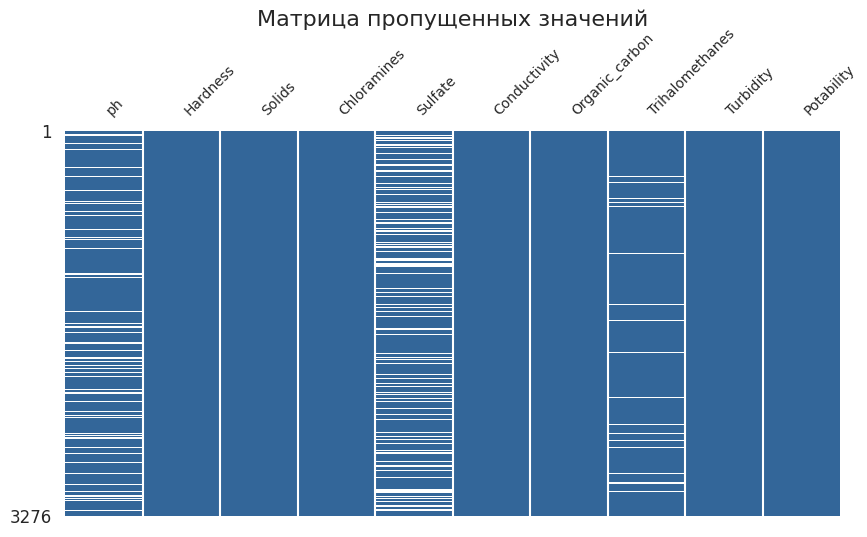

In [4]:
#Дубликаты
duplicates_count = df.duplicated().sum()
print(f"Количество явных дубликатов в датасете: {duplicates_count}\n")

#Красивая обработка пропусков
plt.figure(figsize=(10, 6))
msno.matrix(df, figsize=(10, 5), fontsize=10, sparkline=False, color=(0.2, 0.4, 0.6))
plt.title('Матрица пропущенных значений', fontsize=16, y=1.25)
plt.show()

In [5]:
df['Sulfate'].isna().sum()

np.int64(781)

### Выводы

1. В датасете нет дубликатов, это хорошо
2. В датасете очень много пропусков, особенно выбивается колонка «Sulfate», в которой целых 781 NaN'ов! Это около 24% всего датасета. Если мы будем просто удалять эти строки, то потеряем колоссальное количество информации, поэтому эти пропуски нужно будет каким-то образом заполнить.

## **Заполнение пропусков**

### Мысли

Как мы выяснили ранее, удалять строки с пропущенными значениями мы не можем, так как потеряем очень много данных. В таком случае первое, что приходит в голову, это заполнить строки средним или медианным значением. Дабы избежать влияние выбросов, если они есть, лучше будем заполнять именно медианой.


Но тут может крыться проблема: ведь у питьевой и непитьевой воды химические составы разные, а значит и медианы пропущенных значений разные. Поэтому логичнее будет разделить датасет на два с Potability = 1 / 0, после чего уже эти два датасета заполнить своими медианными значениями,

In [6]:
print("Пропуски ДО:\n", df.isna().sum()[df.isna().sum() > 0], "\n")

cols_with_nan = ['ph', 'Sulfate', 'Trihalomethanes']

for col in cols_with_nan:
    df[col] = df[col].fillna(df.groupby('Potability')[col].transform('median'))

print("Пропуски ПОСЛЕ:\n", df.isna().sum())

Пропуски ДО:
 ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64 

Пропуски ПОСЛЕ:
 ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


### Итог

Мы успешно избавились от пропусков и теперь датафрейм не имеет NaN'ов


## **Анализ выбросов**

Так как ранее мы поняли, что масштаб всех признаков у нас разный, то если мы нарисуем все boxplot'ы на одном графике, то это будет очень плохо, так как часть из них просто «cхлопнется» и мы не сможем нормально проанализировать выбросы. Поэтому отрисуем каждый признак в отдельном окошке.

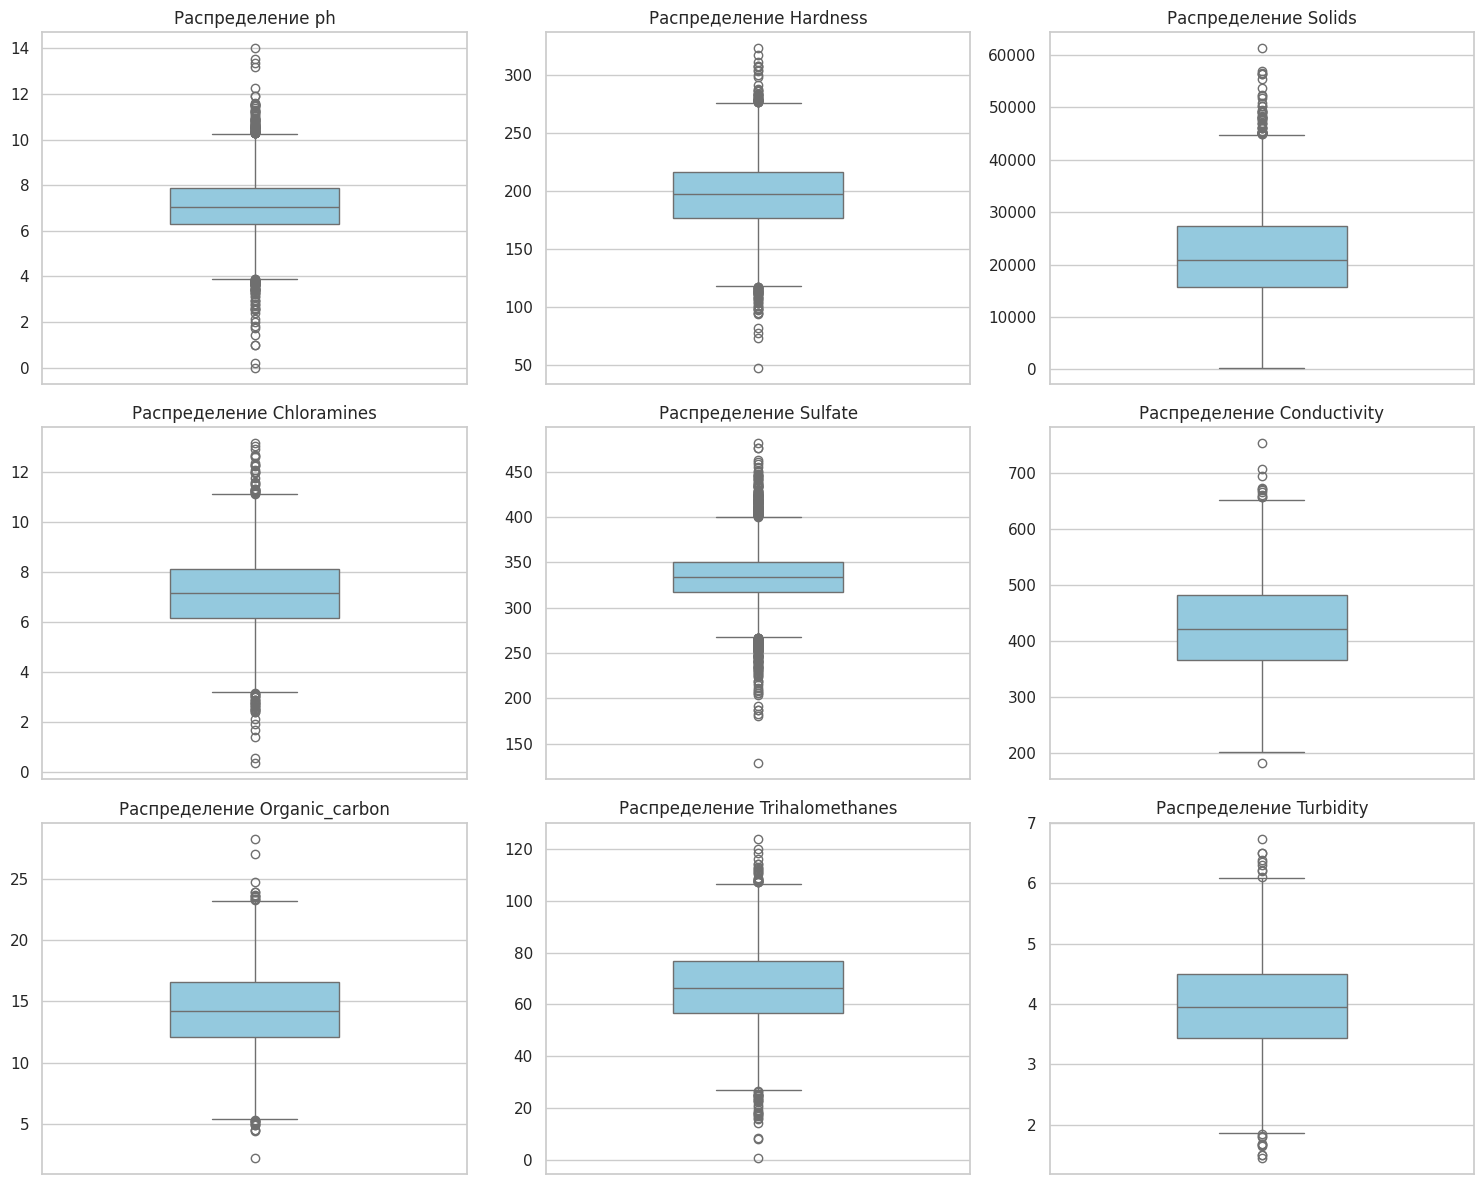

In [7]:
features = df.columns.drop('Potability')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Распределение {col}', fontsize=12)
    axes[i].set_ylabel('') # Убираем подписи осей Y для чистоты

plt.tight_layout()
plt.show()

### Вывод

Как мы видим, во всех характеристиках присутсвует значительная доля выбросов. Особенно выделяются Sulfate и Trihalomethanes.

Первое, что хочется сделать, это взять и избавитсья от этих выбросов, но вспомная специфику нашего датасета, этого делать категорически нельзя

Нам известно, что в природе немало водоемов с катастрофически высоким\низким содержаением каких-то химических элементов и эти данные являются явными индикаторами пригодности воды для питья. Если мы просто удалим из датасета выбросы, то вероятно только ухудшим способность модели верно определять Potability воды.

Поэтому я принял решение не удалять выбросы

## **Анализ распределений признаков в разрезе целевой переменной**

Посмотрим, как разные химические показатели по отдельности могут там говорить о состоянии воды. Есть ли такие хорошие признаки, которые сами по себе неплохо говорят о ее пригодности для питья.

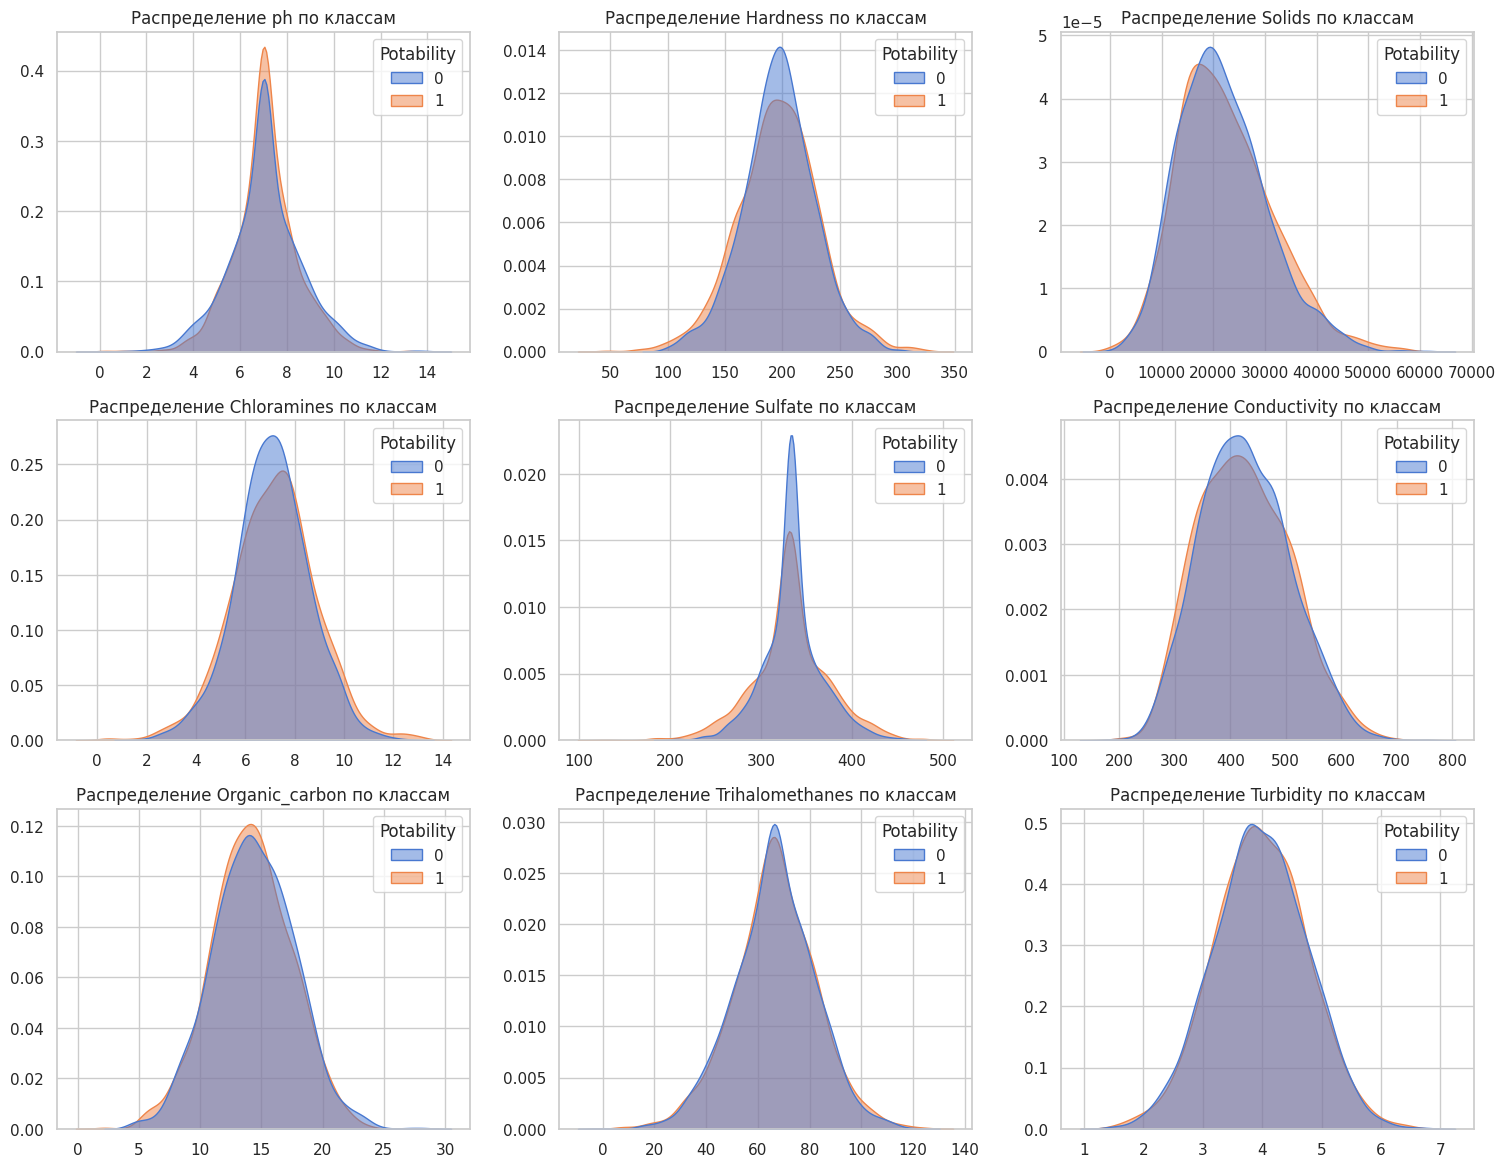

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    #Тут я использовал kdeplot из seaborn -- улучшенный аналог hist из matplotlib
    sns.kdeplot(data=df, x=col, hue='Potability', fill=True,
                common_norm=False, palette='muted', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Распределение {col} по классам', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Как можно видеть, все грустновато. Во многих признаках, таких как Turbidity, распределение химических веществ просто идентично, матожидание везде примерно совпадает. Это усложняет задачу классификации и требует неочевидных решений(

  

## **Корреляционная матрица**

Посмотрим, как признаки связаны между собой. Например, стоит ожидать, что Conductivity связано с Solids, ведь ток проводят именно соли. Если какие-то признаки будут коррелировать, удалим, чтобы упростить работу алгоритму. Посмотрим, есть ли линейная связь между химией и пригодностью воды к потреблению.

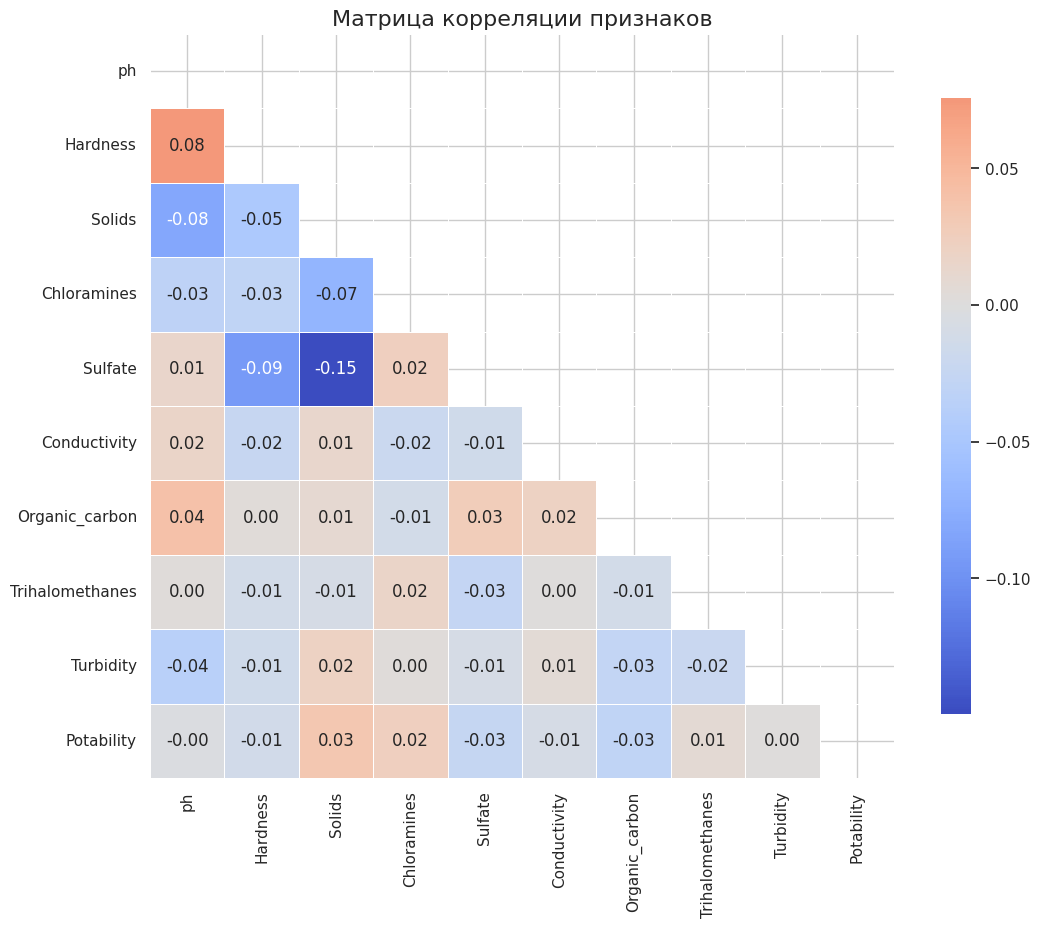

In [12]:
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Матрица корреляции признаков', fontsize=16)
plt.show()

### Вывод

1) Ни одна пара признаков не имеет сильной линейной связи. Это неплохо, так как каждый признак несет в себе уникальную информацию и нет надобности удалять какие-то столбцы

2) Как видно, изначальное предположение о том, что Solids и Conductivity должны быть связаны, оказалось неверным. Так как ток проводят ионные соли, то, видимо высокий уровень Solids в некоторых водоемах обусловлен органикой, которая не проводит ток (можно было предположить, что у них нелинейная связь, но я отдельно посмотрел на их Scatterplot и он представляет из себя просто облако точек, так что никакой другой связи у них все равно нет)

3) Связи с целевой переменной нет. Это в очередной раз показывает сложность датасета для анализа

## **Глобальный итог EDA**

Этот датасет меня немного испугал: классы сильно перемешаны, зависимости носят исключительно нелинейный характер. Скорее всего линейный алгоритмы типа линейной и логистической регрессии будут бесполезны, нужно присмотреться либо к kNN (не забыть про стандартизацию), либо к ансамблевым алгоритмам типа бустинга или рандомфореста (на лекциях этого не было, но если не получится с kNN, придется пробовать их для хоть какого-то результата)

## **Задачи, модели и метрики**

### Задача

Бинарная классификация пригодности воды для потребления

### Выбранные модели

1) **Logistic Regression**: использую как простейшую линейную модель, чтобы подтвердить гипотезу о том, что линейные модели сработают плохо на данном датасете
2) **kNN**: метрический алгоритм, который будет искать "похожие" по составу пробы воды
3) **Random Forest**: так как датасет достаточно тяжелый, причем в нем достаточно много выбросов, я решил также использовать данную ансамблевую модель, так как она обычно хорошо справляется с нелинейными зависимостями

### Метрики качества

Так как в данных есть небольшой дисбаланс 60/40, не буду полагаться только на Accuracy. Основными метриками станут:
1) **Precision**: Мне кажется, что в данной задаче чаще нам важна точность, чем полнота. Уж лучше мы найдем не всю пресную воду, но будем более уверены в пригодности той, которую мы посчитали Potability
2) **F1**: Для баланса точности и полноты
3) **ROC-AUC**: чтобы оценить общую способность модели разделять классы